# COM31006 Computer Vision Assignment 
Adam Willis | acc22aw

Imports
-

In [9]:
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import imagehash
import hashlib
import random
import torch

PART I - Dataset
-

In [10]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),

    # ImageNet normalization
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = datasets.ImageFolder('dataset/train', transform=transform)
test_dataset = datasets.ImageFolder('dataset/test', transform=transform)

In [11]:
train_total = len(train_dataset)
test_total = len(test_dataset)
total = train_total + test_total

In [ ]:
print(f"Dataset Domain: Household Items\n{'-'*50}")
print("dataset/")

print("  train/")
for cls, id in train_dataset.class_to_idx.items():
    print(f"    {cls}/")
    print(f"      {train_dataset.targets.count(id)} images")

print("  test/")
for cls, id in test_dataset.class_to_idx.items():
    print(f"    {cls}/")
    print(f"      {test_dataset.targets.count(id)} images")

print('-'*50)
print(f"Total Images: {total}")
print(f"Train / Test: {train_total} ({train_total/total*100}%) / {test_total} ({test_total/total*100}%)")

Dataset Domain: Household Items
--------------------------------------------------
dataset/
  train/
    book/
      64 images
    bottle/
      64 images
    cutlery/
      64 images
    mug/
      64 images
    shoe/
      64 images
  test/
    book/
      16 images
    bottle/
      16 images
    cutlery/
      16 images
    mug/
      16 images
    shoe/
      16 images
--------------------------------------------------
Total Images: 400
Train / Test: 320 (80.0%) / 80 (20.0%)


In [13]:
# Exact Dataset Validation - checks for overlaps (reused images) in train and test sets by comparing image byte hashes

def convert_to_hashes(dataset):
    hashes = set()

    for i in range(len(dataset)):
        img, _ = dataset[i]
        img_hash = hashlib.sha256(img.numpy().tobytes()).hexdigest()
        hashes.add(img_hash)
    
    return hashes

train_dataset_hashed = convert_to_hashes(train_dataset)
test_dataset_hashed = convert_to_hashes(test_dataset)
overlap_total = train_dataset_hashed.intersection(test_dataset_hashed)

train_hash_total = len(train_dataset_hashed)
test_hash_total = len(test_dataset_hashed)

print(f"Train -> Unique Hashes / Total Images: {train_hash_total} / {train_total}")
print(f" Test -> Unique Hashes / Total Images:  {test_hash_total} /  {test_total}")
print(f"Total -> Unique Hashes / Total Images: {train_hash_total+test_hash_total} / {total}")
print(f"{'-'*50}\nTrain / Test Overlap: {len(overlap_total)}\n{'-'*50}")
if (not len(overlap_total)): print(f"Valid Dataset")

Train -> Unique Hashes / Total Images: 320 / 320
 Test -> Unique Hashes / Total Images:  80 /  80
Total -> Unique Hashes / Total Images: 400 / 400
--------------------------------------------------
Train / Test Overlap: 0
--------------------------------------------------
Valid Dataset


In [14]:
# Similarity Dataset Validation - checks for overlaps (visually similar images) in train and test sets by comparing perceptual image hashes
# Difference in phashes can be used to calculate similarity of images (0 -> identical, 10 -> distinct images)

def convert_to_phashes(dataset):
    hashes = []

    for i in range(len(dataset)):
        img, _ = dataset[i]
        np_img = img.numpy().transpose(1, 2, 0)
        np_img = (np_img * 255).astype(np.uint8)
        pil_img = Image.fromarray(np_img)
        phash = imagehash.phash(pil_img)
        hashes.append(phash)
    
    return hashes

train_dataset_phashed = convert_to_phashes(train_dataset)
test_dataset_phashed = convert_to_phashes(test_dataset)
comparison_total = len(train_dataset_phashed) * len(test_dataset_phashed)

closest_comparisons = []
for hash1 in train_dataset_phashed:
    closest_comparison = min(hash1 - hash2 for hash2 in test_dataset_phashed)
    closest_comparisons.append(closest_comparison)

closest_comparisons = np.array(closest_comparisons)
closest_similarity = closest_comparisons.min()
average_similarity = closest_comparisons.mean()

print(f"Total Comparisons: {comparison_total}")
print(f"Closest Perceptual Similarity: {closest_similarity}")
print(f"Average Perceptual Similarity: {average_similarity:.2f}\n{'-'*50}")
if (closest_similarity>=10): print(f"Valid Dataset")

Total Comparisons: 25600
Closest Perceptual Similarity: 18
Average Perceptual Similarity: 22.05
--------------------------------------------------
Valid Dataset


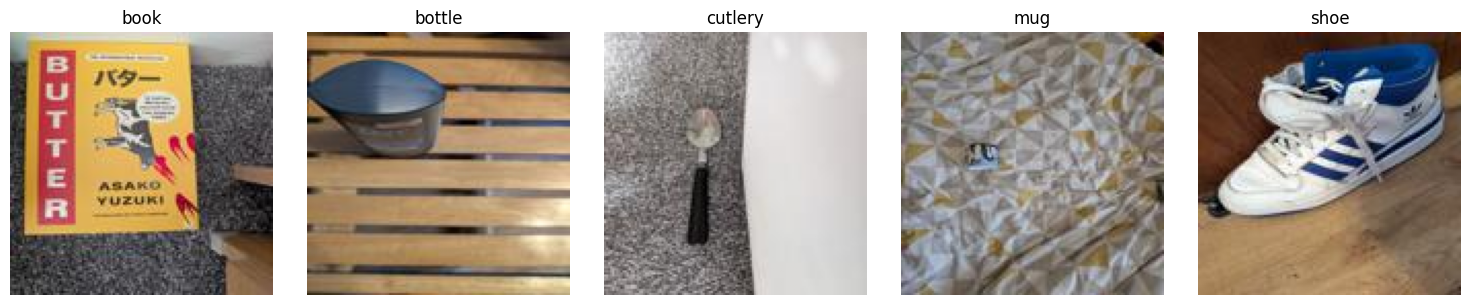

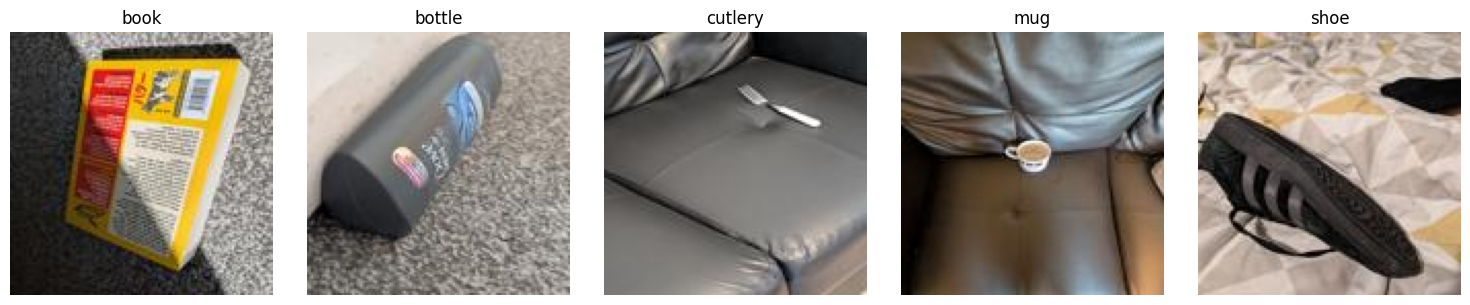

In [15]:
def show_samples(dataset, samples=3):
    # Denormalizing values
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])

    num_classes = len(dataset.classes)
    random.seed(10)

    class_id_dict = {i: [] for i in dataset.class_to_idx.values()}
    for img_id, class_id in enumerate(dataset.targets):
        class_id_dict[class_id].append(img_id)

    plt.figure(figsize=(num_classes * 3, samples * 3))

    for col, (class_name, class_id) in enumerate(dataset.class_to_idx.items()):
        chosen_imgs = random.sample(class_id_dict[class_id], samples)

        for row, i in enumerate(chosen_imgs):
            img, _ = dataset[i]

            # Denormalizing
            img = img.permute(1, 2, 0).cpu()
            img = img * std + mean  
            img = img.clamp(0, 1)
            
            ax = plt.subplot(samples, num_classes, row * num_classes + col + 1)
            ax.imshow(img)
            if row == 0:
                ax.set_title(class_name)
            ax.axis("off")

    plt.tight_layout()
    plt.show()

show_samples(train_dataset, samples=1)
show_samples(test_dataset, samples=1)

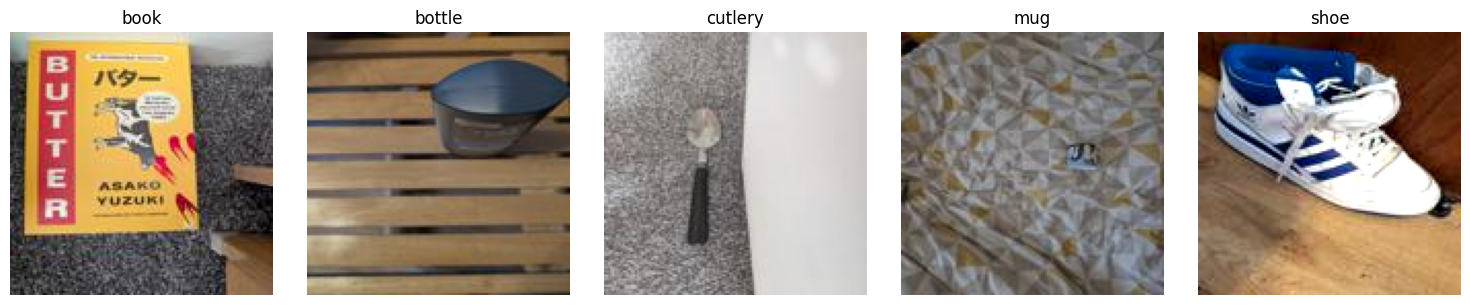

In [19]:
# Data Augmentation - random changes are applied to the training dataset to increase the performance of the model and decrease chances of overfitting

augmented_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

augmented_train_dataset = datasets.ImageFolder('dataset/train', transform=augmented_transform)

show_samples(augmented_train_dataset, samples=1)

PART II - Exploring Existing CNN Architectures
-

In [ ]:
# TODO: test AlexNet, ResNet, MobileNet
#
# TODO: functions for
#           Load model (load_model)
#           Replace classifier layer (replace_classifier)
#           Fine-tune (train) (train_model)
#           (evaluate_model)
#           (analyse_model) below
#           Evaluate accuracy (F1 score, confusion matrix)
#           Compute parameters and other stats
#           Print top-5 largest layers
#
# TODO: call above on each of the chosen architectures


In [ ]:
def load_model():
    pass

In [ ]:
def describe_model_architecture():
    pass

In [ ]:
def edit_model_classifier():
    pass

In [ ]:
def fine_tune_model():
    pass

In [ ]:
def evaluate_model():
    pass

In [ ]:
def analyse_model_parameters():
    pass

In [ ]:
def explore_model(model_name):
    model = load_model(model_name)
    describe_model_architecture(model)
    model = edit_model_classifier(model)
    fine_tune_model(model, augmented_train_dataset)
    results = evaluate_model(model, test_dataset)
    parameter_stats = analyse_model_parameters(model)
    return results, parameter_stats

alexnet_results, alexnet_parameter_stats = explore_model("alexnet")
resnet_results, resnet_parameter_stats = explore_model("resnet")
mobilenet_results, mobilenet_parameter_stats = explore_model("mobilenet")

In [ ]:
# TODO: compare all of the results (accuracy, confusion matrix, f1 score) and parameter stats (total, top 5 largest layers)

PART III - Comparing Classical Filters
-

PART IV - Modifying Architecture using Filter Selection
-

PART V - Comparison and Evaluation
-